In [116]:
import numpy as np
import seaborn as sns
import pandas as pd
import matplotlib.pyplot as plt

import time
import cv2

import timm
import torch
import torch.nn as nn
from torch.optim import AdamW
from torch.optim.lr_scheduler import CosineAnnealingWarmRestarts
from torch.utils.data import DataLoader, WeightedRandomSampler
from torchvision import transforms

from transformers import SwinForImageClassification, SwinConfig, Swinv2ForImageClassification

from sklearn.model_selection import train_test_split
from sklearn.metrics import classification_report, confusion_matrix

from dataset import APTOSDataset, IDRiDDataset

from PIL import Image
import os

from torch.optim.lr_scheduler import CosineAnnealingLR

In [8]:
csv_path = "aptos_dataset/train.csv"
image_dir = "aptos_dataset/train_images"

df = pd.read_csv(csv_path)

In [9]:
# Create ordinal thresholds for each label
def make_thresholds(label):
    return [1 if label >= i else 0 for i in range(1, 5)]

df['thresholds'] = df['diagnosis'].apply(make_thresholds)

In [10]:
train_df, val_df = train_test_split(
    df,
    test_size=0.2,
    stratify=df['diagnosis'],
    random_state=78
)

In [11]:
def crop_fundus(image):
    gray = np.array(image.convert('L'))
    _, thresh = cv2.threshold(gray, 10, 255, cv2.THRESH_BINARY)

    contours, _ = cv2.findContours(thresh, cv2.RETR_EXTERNAL, cv2.CHAIN_APPROX_SIMPLE)
    
    if contours:
        largest = max(contours, key=cv2.contourArea)
        x, y, w, h = cv2.boundingRect(largest)
        image = image.crop((x, y, x + w, y + h))
    
    return image

In [12]:
class SquarePad:
    def __call__(self, image):
        w, h = image.size
        max_side = max(w, h)
        pad_left = (max_side - w) // 2
        pad_top = (max_side - h) // 2
        padding = (pad_left, pad_top, max_side - w - pad_left, max_side - h - pad_top)
        return transforms.functional.pad(image, padding, fill=0)

In [97]:
transform_train = transforms.Compose([
    # transforms.Lambda(crop_fundus),
    # SquarePad(),
    transforms.Resize((224, 224)), # for swin v2
    transforms.RandomHorizontalFlip(),
    transforms.RandomVerticalFlip(),
    transforms.RandomRotation(15),
    transforms.ColorJitter(brightness=0.3, contrast=0.3, saturation=0.2),
    transforms.GaussianBlur(kernel_size=3, sigma=(0.1, 1.0)),
    transforms.ToTensor(),
    transforms.Normalize(
        mean=[0.485, 0.456, 0.406], 
        std=[0.229, 0.224, 0.225]
    )
])

In [98]:
transform_val = transforms.Compose([
    # transforms.Lambda(crop_fundus),
    # SquarePad(),
    transforms.Resize((224,224)),
    transforms.ToTensor(),
    transforms.Normalize(
        mean=[0.485, 0.456, 0.406],
        std=[0.229, 0.224, 0.225]
    )
])

In [75]:
train_dataset = APTOSDataset(train_df, image_dir, transform_train)
val_dataset = APTOSDataset(val_df, image_dir, transform_val)

In [76]:
class_counts_tr = train_df['diagnosis'].value_counts().sort_index().values
class_counts_vl = val_df['diagnosis'].value_counts().sort_index().values

print(train_df.shape)
print(val_df.shape)
print(f"Class counts of train set: {class_counts_tr}")
print(f"Class counts of val set: {class_counts_vl}")

(2929, 3)
(733, 3)
Class counts of train set: [1444  296  799  154  236]
Class counts of val set: [361  74 200  39  59]


In [77]:
class_weights = 1. / class_counts_tr
sample_weights = torch.tensor(
    train_df['diagnosis'].map(
        {i: class_weights[i] for i in range(len(class_weights))}
    ).values,
    dtype=torch.float
)

sampler = WeightedRandomSampler(
    weights = sample_weights,
    num_samples=len(sample_weights),
    replacement=True
)

In [78]:
train_loader = DataLoader(
    train_dataset,
    batch_size=32,
    sampler = sampler
)

val_loader = DataLoader(
    val_dataset,
    batch_size=32,
    shuffle = False
)

In [79]:
images, labels = next(iter(train_loader))

print("Images shape:", images.shape)
print("Labels shape:", labels.shape)
print("Unique labels in batch:", labels.unique())

Images shape: torch.Size([32, 3, 256, 256])
Labels shape: torch.Size([32, 4])
Unique labels in batch: tensor([0., 1.])


In [20]:
# WeightedRandomSampler samples the minority classes so in one batch, the class counts are approximately equal

images, labels = next(iter(train_loader))
unique, counts = torch.unique(labels, return_counts=True)
print(dict(zip(unique.tolist(), counts.tolist())))

{0.0: 69, 1.0: 59}


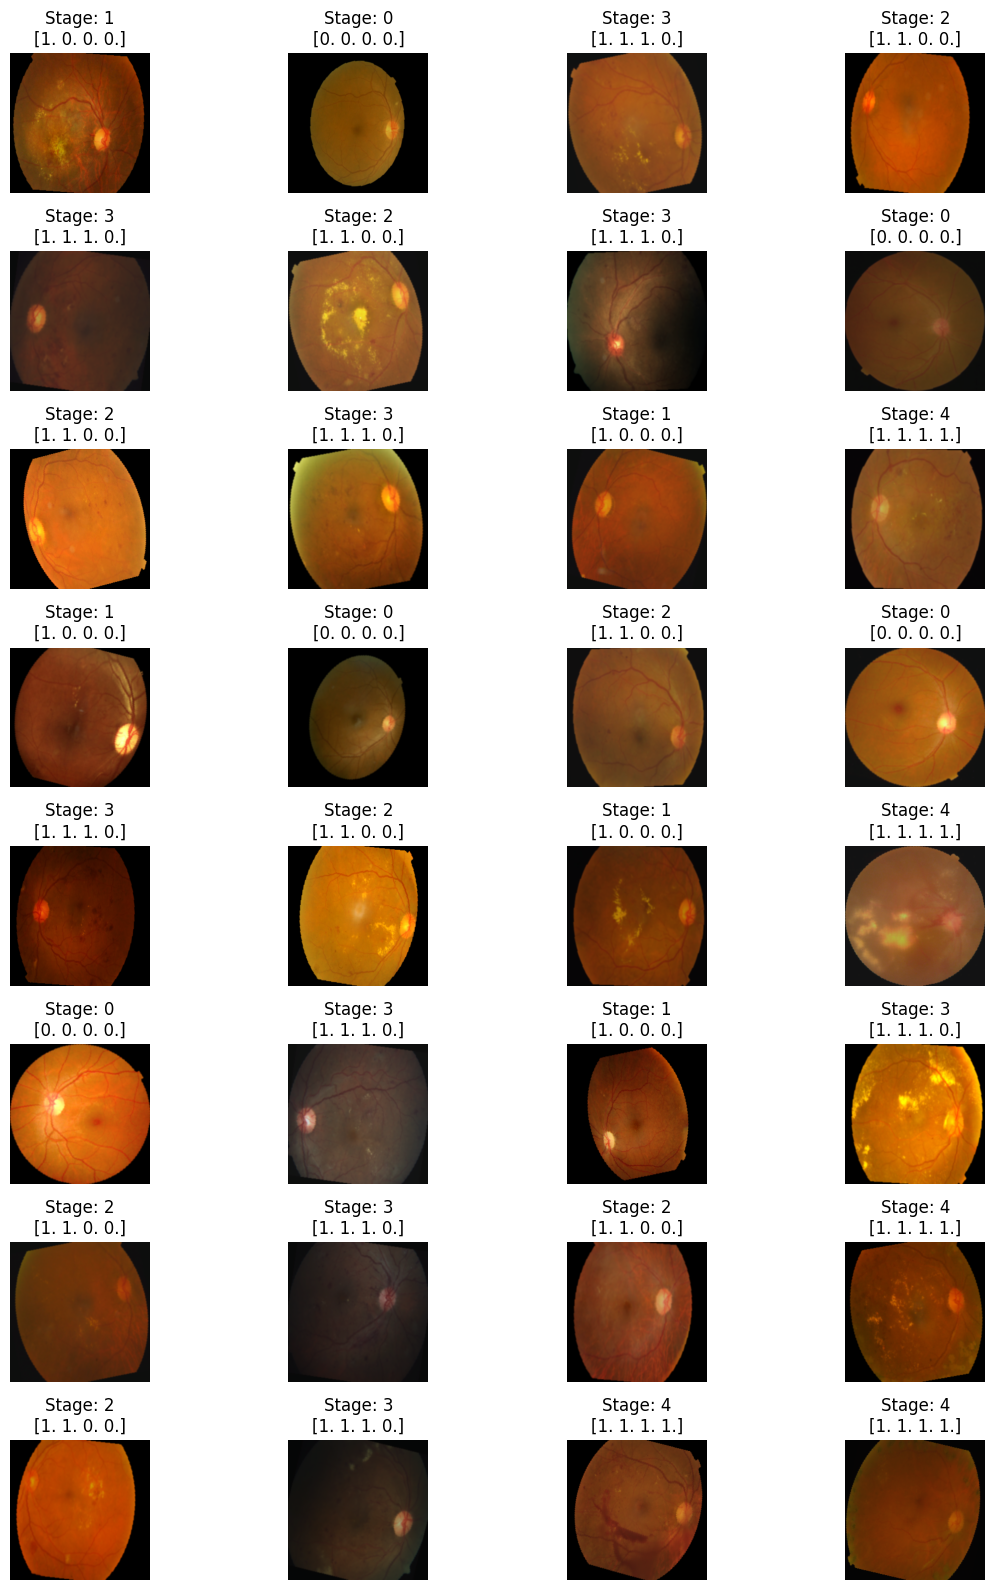

In [80]:
# visualizing one whole batch, transformations are visible in the images
# modified for ordinal

mean = np.array([0.485, 0.456, 0.406])
std  = np.array([0.229, 0.224, 0.225])

figs, axes = plt.subplots(8, 4, figsize=(12, 16))
axes = axes.flatten()

for i in range(len(images)):
    img = images[i].cpu().numpy().transpose(1, 2, 0)
    img = std * img + mean
    img = np.clip(img, 0, 1)

    axes[i].imshow(img)

    # Get ordinal label vector
    threshold_vec = labels[i].cpu().numpy()

    # Convert thresholds to stage (sum of ones)
    stage = int(threshold_vec.sum())

    axes[i].set_title(f"Stage: {stage}\n{threshold_vec}")
    axes[i].axis('off')

plt.tight_layout()
plt.show()

In [81]:
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print(device)

cuda


In [82]:
train_labels = pd.read_csv(r'D:\B. Disease Grading\2. Groundtruths\a. IDRiD_Disease Grading_Training Labels.csv')
train_labels = train_labels[['Image name', 'Retinopathy grade']]
test_labels = pd.read_csv(r'D:\B. Disease Grading\2. Groundtruths\b. IDRiD_Disease Grading_Testing Labels.csv')
test_labels = test_labels[['Image name', 'Retinopathy grade']]

all_labels = pd.concat([train_labels, test_labels], ignore_index=True)

In [83]:
train_imgs = r'D:\B. Disease Grading\1. Original Images\a. Training Set'
test_imgs = r'D:\B. Disease Grading\1. Original Images\b. Testing Set'

def add_paths(df, img_dir):
    df['full_path'] = df['Image name'].apply(lambda x: os.path.join(img_dir, x + '.jpg'))
    return df

train_labels = add_paths(train_labels, train_imgs)
test_labels = add_paths(test_labels, test_imgs)
all_data = pd.concat([train_labels, test_labels], ignore_index=True)

In [84]:
cross_dataset = IDRiDDataset(all_data, transform=transform_val)
cross_loader = DataLoader(cross_dataset, batch_size=32, shuffle = False)

In [85]:
print(len(cross_dataset))

516


In [86]:
print(all_data['Retinopathy grade'].value_counts())

Retinopathy grade
2    168
0    168
3     93
4     62
1     25
Name: count, dtype: int64


#### DINOv2

In [36]:
dino_model = timm.create_model('vit_small_patch14_dinov2.lvd142m', pretrained=True, num_classes=4, img_size = 224)
dino_model = dino_model.to(device)

In [37]:
print(dino_model.head)

Linear(in_features=384, out_features=4, bias=True)


In [38]:
optimizer = torch.optim.AdamW(dino_model.parameters(), lr=1e-3, weight_decay=0.05)
scheduler = torch.optim.lr_scheduler.CosineAnnealingLR(optimizer, T_max=15)
scaler = torch.amp.GradScaler('cuda')
criterion = nn.BCEWithLogitsLoss()

In [39]:
num_epochs = 15
best_val_acc = 0.0

for epoch in range(num_epochs):
    epoch_start = time.time()

    dino_model.train()
    running_loss = 0.0
    correct = 0
    total = 0

    for images, labels in train_loader:
        images = images.to(device)
        labels = labels.to(device)

        optimizer.zero_grad()

        with torch.amp.autocast('cuda'):
            outputs = dino_model(images)
            loss = criterion(outputs, labels)

        scaler.scale(loss).backward()
        scaler.step(optimizer)
        scaler.update()

        running_loss += loss.item()

        probs = torch.sigmoid(outputs)
        predicted = (probs > 0.5).sum(dim=1)
        actual = labels.sum(dim=1)
        correct += (predicted == actual).sum().item()
        total += labels.size(0)

    scheduler.step()

    train_acc = correct / total
    train_loss = running_loss / len(train_loader)


    dino_model.eval()
    val_loss = 0.0
    val_correct = 0
    val_total = 0

    with torch.no_grad():
        for images, labels in val_loader:
            images = images.to(device)
            labels = labels.to(device)

            with torch.amp.autocast('cuda'):
                outputs = dino_model(images)
                loss = criterion(outputs, labels)

            val_loss += loss.item()
            probs = torch.sigmoid(outputs)
            predicted = (probs > 0.5).sum(dim=1)
            actual = labels.sum(dim=1)
            val_correct += (predicted == actual).sum().item()
            val_total += labels.size(0)

    val_acc = val_correct / val_total
    val_loss = val_loss / len(val_loader)

    epoch_time = (time.time() - epoch_start) / 60

    if val_acc > best_val_acc:
        best_val_acc = val_acc
        torch.save(dino_model.state_dict(), 'best_dinov2_small_model.pth')
        print(f'Best model saved with validation accuracy of {val_acc:.2f}')


    print(f"Epoch [{epoch+1}/{num_epochs}] "
          f"Train Loss: {train_loss:.4f} Train Acc: {train_acc:.4f} "
          f"Val Loss: {val_loss:.4f} Val Acc: {val_acc:.4f} "
          f"Time: {epoch_time:.2f} min")

Best model saved with validation accuracy of 0.10
Epoch [1/15] Train Loss: 0.6711 Train Acc: 0.1987 Val Loss: 0.5268 Val Acc: 0.1010 Time: 6.16 min


KeyboardInterrupt: 

#### DeiT Small

In [46]:
deit_model = timm.create_model('deit_small_patch16_224', pretrained=True)

deit_model.head = nn.Linear(deit_model.head.in_features, 4)
deit_model = deit_model.to(device)

In [47]:
criterion = nn.BCEWithLogitsLoss()

optimizer = torch.optim.AdamW(deit_model.parameters(), lr=1e-4, weight_decay=0.05)
scheduler = torch.optim.lr_scheduler.CosineAnnealingLR(optimizer, T_max=15)
scaler = torch.amp.GradScaler('cuda')

In [48]:
num_epochs = 15
best_val_acc = 0.0

for epoch in range(num_epochs):
    epoch_start = time.time()

    deit_model.train()
    running_loss = 0.0
    correct = 0
    total = 0

    for images, labels in train_loader:
        images = images.to(device)
        labels = labels.to(device)

        optimizer.zero_grad()

        with torch.amp.autocast('cuda'):
            outputs = deit_model(images)
            loss = criterion(outputs, labels)

        scaler.scale(loss).backward()
        scaler.step(optimizer)
        scaler.update()

        running_loss += loss.item()

        probs = torch.sigmoid(outputs)
        predicted = (probs > 0.5).sum(dim=1)
        actual = labels.sum(dim=1)
        correct += (predicted == actual).sum().item()
        total += labels.size(0)

    scheduler.step()

    train_acc = correct / total
    train_loss = running_loss / len(train_loader)


    deit_model.eval()
    val_loss = 0.0
    val_correct = 0
    val_total = 0

    with torch.no_grad():
        for images, labels in val_loader:
            images = images.to(device)
            labels = labels.to(device)

            with torch.amp.autocast('cuda'):
                outputs = deit_model(images)
                loss = criterion(outputs, labels)

            val_loss += loss.item()
            probs = torch.sigmoid(outputs)
            predicted = (probs > 0.5).sum(dim=1)
            actual = labels.sum(dim=1)
            val_correct += (predicted == actual).sum().item()
            val_total += labels.size(0)

    val_acc = val_correct / val_total
    val_loss = val_loss / len(val_loader)

    epoch_time = (time.time() - epoch_start) / 60

    if val_acc > best_val_acc:
        best_val_acc = val_acc
        torch.save(deit_model.state_dict(), 'best_deit_small_model.pth')
        print(f'Best model saved with validation accuracy of {val_acc:.2f}')


    print(f"Epoch [{epoch+1}/{num_epochs}] "
          f"Train Loss: {train_loss:.4f} Train Acc: {train_acc:.4f} "
          f"Val Loss: {val_loss:.4f} Val Acc: {val_acc:.4f} "
          f"Time: {epoch_time:.2f} min")

Best model saved with validation accuracy of 0.70
Epoch [1/15] Train Loss: 0.3208 Train Acc: 0.5401 Val Loss: 0.1988 Val Acc: 0.7040 Time: 6.06 min
Best model saved with validation accuracy of 0.74
Epoch [2/15] Train Loss: 0.2401 Train Acc: 0.6654 Val Loss: 0.1694 Val Acc: 0.7422 Time: 6.36 min
Best model saved with validation accuracy of 0.76
Epoch [3/15] Train Loss: 0.2114 Train Acc: 0.7026 Val Loss: 0.1641 Val Acc: 0.7585 Time: 6.22 min
Best model saved with validation accuracy of 0.78
Epoch [4/15] Train Loss: 0.1870 Train Acc: 0.7443 Val Loss: 0.1577 Val Acc: 0.7804 Time: 6.41 min
Epoch [5/15] Train Loss: 0.1681 Train Acc: 0.7610 Val Loss: 0.1856 Val Acc: 0.7381 Time: 6.30 min
Epoch [6/15] Train Loss: 0.1427 Train Acc: 0.8033 Val Loss: 0.1765 Val Acc: 0.7790 Time: 6.27 min
Epoch [7/15] Train Loss: 0.1150 Train Acc: 0.8433 Val Loss: 0.1821 Val Acc: 0.7626 Time: 6.15 min
Epoch [8/15] Train Loss: 0.1081 Train Acc: 0.8498 Val Loss: 0.1878 Val Acc: 0.7776 Time: 6.13 min
Best model saved

In [49]:
deit_model.load_state_dict(torch.load('best_deit_small_model.pth'))

C:\Users\Ashraf\AppData\Local\Temp\ipykernel_13404\1916244248.py:1: FutureWarning: You are using `torch.load` with `weights_only=False` (the current default value), which uses the default pickle module implicitly. It is possible to construct malicious pickle data which will execute arbitrary code during unpickling (See https://github.com/pytorch/pytorch/blob/main/SECURITY.md#untrusted-models for more details). In a future release, the default value for `weights_only` will be flipped to `True`. This limits the functions that could be executed during unpickling. Arbitrary objects will no longer be allowed to be loaded via this mode unless they are explicitly allowlisted by the user via `torch.serialization.add_safe_globals`. We recommend you start setting `weights_only=True` for any use case where you don't have full control of the loaded file. Please open an issue on GitHub for any issues related to this experimental feature.
  deit_model.load_state_dict(torch.load('best_deit_small_mode

<All keys matched successfully>

In [50]:
deit_model.eval()

cross_correct = 0
cross_total = 0

with torch.no_grad():
    for images, labels in cross_loader:
        images, labels = images.to(device), labels.to(device)

        with torch.amp.autocast('cuda'):
            outputs = deit_model(images)

        probs = torch.sigmoid(outputs)
        predicted = (probs > 0.5).sum(dim=1)
        actual = labels.sum(dim=1)
        cross_correct += (predicted == actual).sum().item()
        cross_total += labels.size(0)

cross_acc = 100 * cross_correct / cross_total
print(f"Cross-dataset (IDRiD) Accuracy: {cross_acc:.2f}%")

Cross-dataset (IDRiD) Accuracy: 43.41%


#### Swin Transformer

In [87]:
# # We configure it for 5 classes (0: No DR, 1: Mild, 2: Moderate, 3: Severe, 4: Proliferative)
# configuration = SwinConfig(
#     image_size=224, 
#     num_channels=3, 
#     num_labels=5
# )

# Load pretrained weights from Microsoft's Swin-Tiny
model = Swinv2ForImageClassification.from_pretrained(
    'microsoft/swinv2-tiny-patch4-window8-256',
    num_labels=4,
    ignore_mismatched_sizes=True,
    use_safetensors=True
)
model.classifier = nn.Sequential(
    nn.Linear(768, 4)
)
model.to(device)

Loading weights:   0%|          | 0/245 [00:00<?, ?it/s]

Swinv2ForImageClassification LOAD REPORT from: microsoft/swinv2-tiny-patch4-window8-256
Key               | Status   |                                                                                          
------------------+----------+------------------------------------------------------------------------------------------
classifier.weight | MISMATCH | Reinit due to size mismatch - ckpt: torch.Size([1000, 768]) vs model:torch.Size([4, 768])
classifier.bias   | MISMATCH | Reinit due to size mismatch - ckpt: torch.Size([1000]) vs model:torch.Size([4])          

Notes:
- MISMATCH	:ckpt weights were loaded, but they did not match the original empty weight shapes.


Swinv2ForImageClassification(
  (swinv2): Swinv2Model(
    (embeddings): Swinv2Embeddings(
      (patch_embeddings): Swinv2PatchEmbeddings(
        (projection): Conv2d(3, 96, kernel_size=(4, 4), stride=(4, 4))
      )
      (norm): LayerNorm((96,), eps=1e-05, elementwise_affine=True)
      (dropout): Dropout(p=0.0, inplace=False)
    )
    (encoder): Swinv2Encoder(
      (layers): ModuleList(
        (0): Swinv2Stage(
          (blocks): ModuleList(
            (0): Swinv2Layer(
              (attention): Swinv2Attention(
                (self): Swinv2SelfAttention(
                  (continuous_position_bias_mlp): Sequential(
                    (0): Linear(in_features=2, out_features=512, bias=True)
                    (1): ReLU(inplace=True)
                    (2): Linear(in_features=512, out_features=3, bias=False)
                  )
                  (query): Linear(in_features=96, out_features=96, bias=True)
                  (key): Linear(in_features=96, out_features=96, bias

In [88]:
print(type(model))
print(model.config.image_size)

<class 'transformers.models.swinv2.modeling_swinv2.Swinv2ForImageClassification'>
256


In [89]:
optimizer = torch.optim.AdamW(model.parameters(), lr = 1e-4, weight_decay = 0.05)
scheduler = CosineAnnealingLR(optimizer, T_max=15)
criterion = torch.nn.BCEWithLogitsLoss()

In [ ]:
# def mixup(images, labels, alpha=0.2, p=0.5):
#     if torch.rand(1).item() > p:
#         return images, labels
#     lam = torch.distributions.Beta(alpha, alpha).sample().to(images.device)
#     index = torch.randperm(images.size(0)).to(images.device)
#     mixed_images = lam * images + (1 - lam) * images[index]
#     mixed_labels = lam * labels + (1 - lam) * labels[index]
#     return mixed_images, mixed_labels

In [90]:
num_epochs = 15
best_val_acc = 0.0

for epoch in range(num_epochs):
    model.train()
    running_loss = 0.0
    correct = 0
    total = 0
    
    for i, (images, labels) in enumerate(train_loader):
        images, labels = images.to(device), labels.to(device)
        
        optimizer.zero_grad()
        
        outputs = model(images)
        logits = outputs.logits
        
        loss = criterion(logits, labels)
        
        loss.backward()        
        optimizer.step()
        
        running_loss += loss.item()

        probs = torch.sigmoid(logits)
        predicted = (probs > 0.5).sum(dim=1)
        actual = (labels > 0.5).sum(dim=1)
        correct += (predicted == actual).sum().item()
        total += labels.size(0)
        
        if (i + 1) % 10 == 0:
            print(f"Epoch [{epoch+1}/{num_epochs}], Step [{i+1}/{len(train_loader)}], Loss: {loss.item():.4f}")

    train_acc = 100 * correct / total
    
    model.eval()
    val_loss = 0.0
    val_correct = 0
    val_total = 0
    
    with torch.no_grad():
        for images, labels in val_loader:
            images, labels = images.to(device), labels.to(device)
            
            outputs = model(images)
            logits = outputs.logits
            
            loss = criterion(logits, labels)
            val_loss += loss.item()
             
            probs = torch.sigmoid(logits)
            predicted = (probs > 0.5).sum(dim=1)
            actual = labels.sum(dim=1)
            val_correct += (predicted == actual).sum().item()
            val_total += labels.size(0)
            
    val_acc = 100 * val_correct / val_total
    print(f"--- Epoch {epoch+1} Summary: Train Loss: {running_loss/len(train_loader):.4f}, Train Acc: {train_acc:.2f}%, Val Acc: {val_acc:.2f}% ---")

    scheduler.step()

    if val_acc > best_val_acc:
        best_val_acc = val_acc
        torch.save(model.state_dict(), 'best_swinv2_ordinal.pth')
        print(f'Best model saved with validation accuracy of {val_acc:.2f}%')
        
print("Swin-V2 Training Test Complete.")

Epoch [1/15], Step [10/92], Loss: 0.4452
Epoch [1/15], Step [20/92], Loss: 0.3782
Epoch [1/15], Step [30/92], Loss: 0.2786
Epoch [1/15], Step [40/92], Loss: 0.3281
Epoch [1/15], Step [50/92], Loss: 0.2827
Epoch [1/15], Step [60/92], Loss: 0.3837
Epoch [1/15], Step [70/92], Loss: 0.2084
Epoch [1/15], Step [80/92], Loss: 0.2525
Epoch [1/15], Step [90/92], Loss: 0.2374
--- Epoch 1 Summary: Train Loss: 0.3213, Train Acc: 53.98%, Val Acc: 78.04% ---
Best model saved with validation accuracy of 78.04%
Epoch [2/15], Step [10/92], Loss: 0.2719
Epoch [2/15], Step [20/92], Loss: 0.2200
Epoch [2/15], Step [30/92], Loss: 0.1860
Epoch [2/15], Step [40/92], Loss: 0.2225
Epoch [2/15], Step [50/92], Loss: 0.2562
Epoch [2/15], Step [60/92], Loss: 0.2261
Epoch [2/15], Step [70/92], Loss: 0.2837
Epoch [2/15], Step [80/92], Loss: 0.1773
Epoch [2/15], Step [90/92], Loss: 0.1973
--- Epoch 2 Summary: Train Loss: 0.2297, Train Acc: 67.29%, Val Acc: 80.08% ---
Best model saved with validation accuracy of 80.08

In [91]:
model.load_state_dict(torch.load('best_swinv2_ordinal.pth'))
model

C:\Users\Ashraf\AppData\Local\Temp\ipykernel_8996\971977570.py:1: FutureWarning: You are using `torch.load` with `weights_only=False` (the current default value), which uses the default pickle module implicitly. It is possible to construct malicious pickle data which will execute arbitrary code during unpickling (See https://github.com/pytorch/pytorch/blob/main/SECURITY.md#untrusted-models for more details). In a future release, the default value for `weights_only` will be flipped to `True`. This limits the functions that could be executed during unpickling. Arbitrary objects will no longer be allowed to be loaded via this mode unless they are explicitly allowlisted by the user via `torch.serialization.add_safe_globals`. We recommend you start setting `weights_only=True` for any use case where you don't have full control of the loaded file. Please open an issue on GitHub for any issues related to this experimental feature.
  model.load_state_dict(torch.load('best_swinv2_ordinal.pth'))


Swinv2ForImageClassification(
  (swinv2): Swinv2Model(
    (embeddings): Swinv2Embeddings(
      (patch_embeddings): Swinv2PatchEmbeddings(
        (projection): Conv2d(3, 96, kernel_size=(4, 4), stride=(4, 4))
      )
      (norm): LayerNorm((96,), eps=1e-05, elementwise_affine=True)
      (dropout): Dropout(p=0.0, inplace=False)
    )
    (encoder): Swinv2Encoder(
      (layers): ModuleList(
        (0): Swinv2Stage(
          (blocks): ModuleList(
            (0): Swinv2Layer(
              (attention): Swinv2Attention(
                (self): Swinv2SelfAttention(
                  (continuous_position_bias_mlp): Sequential(
                    (0): Linear(in_features=2, out_features=512, bias=True)
                    (1): ReLU(inplace=True)
                    (2): Linear(in_features=512, out_features=3, bias=False)
                  )
                  (query): Linear(in_features=96, out_features=96, bias=True)
                  (key): Linear(in_features=96, out_features=96, bias

In [92]:
all_preds = []
all_labels = []
with torch.no_grad():
    for images, labels in cross_loader:
        images, labels = images.to(device), labels.to(device)
        outputs = model(images)
        logits = outputs.logits
        probs = torch.sigmoid(logits)
        predicted = (probs > 0.5).sum(dim=1)
        actual = labels.sum(dim=1)
        all_preds.extend(predicted.cpu().numpy())
        all_labels.extend(actual.cpu().numpy())

print(confusion_matrix(all_labels, all_preds))
print(classification_report(all_labels, all_preds))

[[ 97  56  12   1   2]
 [ 14   7   4   0   0]
 [  8  25 128   2   5]
 [  1   1  64  16  11]
 [  0   1  27  11  23]]
              precision    recall  f1-score   support

         0.0       0.81      0.58      0.67       168
         1.0       0.08      0.28      0.12        25
         2.0       0.54      0.76      0.64       168
         3.0       0.53      0.17      0.26        93
         4.0       0.56      0.37      0.45        62

    accuracy                           0.53       516
   macro avg       0.51      0.43      0.43       516
weighted avg       0.61      0.53      0.53       516



#### Testing with Swin V1

In [99]:
# We configure it for 5 classes (0: No DR, 1: Mild, 2: Moderate, 3: Severe, 4: Proliferative)
configuration = SwinConfig(
    image_size=224, 
    num_channels=3, 
    num_labels=5
)

# Load pretrained weights from Microsoft's Swin-Tiny
model_v1 = SwinForImageClassification.from_pretrained(
    "microsoft/swin-tiny-patch4-window7-224", 
    config=configuration, 
    ignore_mismatched_sizes=True
)
model_v1.to(device)

Loading weights:   0%|          | 0/233 [00:00<?, ?it/s]

SwinForImageClassification LOAD REPORT from: microsoft/swin-tiny-patch4-window7-224
Key               | Status   |                                                                                          
------------------+----------+------------------------------------------------------------------------------------------
classifier.bias   | MISMATCH | Reinit due to size mismatch - ckpt: torch.Size([1000]) vs model:torch.Size([5])          
classifier.weight | MISMATCH | Reinit due to size mismatch - ckpt: torch.Size([1000, 768]) vs model:torch.Size([5, 768])

Notes:
- MISMATCH	:ckpt weights were loaded, but they did not match the original empty weight shapes.


SwinForImageClassification(
  (swin): SwinModel(
    (embeddings): SwinEmbeddings(
      (patch_embeddings): SwinPatchEmbeddings(
        (projection): Conv2d(3, 96, kernel_size=(4, 4), stride=(4, 4))
      )
      (norm): LayerNorm((96,), eps=1e-05, elementwise_affine=True)
      (dropout): Dropout(p=0.0, inplace=False)
    )
    (encoder): SwinEncoder(
      (layers): ModuleList(
        (0): SwinStage(
          (blocks): ModuleList(
            (0): SwinLayer(
              (layernorm_before): LayerNorm((96,), eps=1e-05, elementwise_affine=True)
              (attention): SwinAttention(
                (self): SwinSelfAttention(
                  (query): Linear(in_features=96, out_features=96, bias=True)
                  (key): Linear(in_features=96, out_features=96, bias=True)
                  (value): Linear(in_features=96, out_features=96, bias=True)
                  (dropout): Dropout(p=0.0, inplace=False)
                )
                (output): SwinSelfOutput(
        

In [124]:
model_v1.load_state_dict(torch.load('best_swin_dr_model.pth'))
model_v1

C:\Users\Ashraf\AppData\Local\Temp\ipykernel_8996\812828528.py:1: FutureWarning: You are using `torch.load` with `weights_only=False` (the current default value), which uses the default pickle module implicitly. It is possible to construct malicious pickle data which will execute arbitrary code during unpickling (See https://github.com/pytorch/pytorch/blob/main/SECURITY.md#untrusted-models for more details). In a future release, the default value for `weights_only` will be flipped to `True`. This limits the functions that could be executed during unpickling. Arbitrary objects will no longer be allowed to be loaded via this mode unless they are explicitly allowlisted by the user via `torch.serialization.add_safe_globals`. We recommend you start setting `weights_only=True` for any use case where you don't have full control of the loaded file. Please open an issue on GitHub for any issues related to this experimental feature.
  model_v1.load_state_dict(torch.load('best_swin_dr_model.pth')

SwinForImageClassification(
  (swin): SwinModel(
    (embeddings): SwinEmbeddings(
      (patch_embeddings): SwinPatchEmbeddings(
        (projection): Conv2d(3, 96, kernel_size=(4, 4), stride=(4, 4))
      )
      (norm): LayerNorm((96,), eps=1e-05, elementwise_affine=True)
      (dropout): Dropout(p=0.0, inplace=False)
    )
    (encoder): SwinEncoder(
      (layers): ModuleList(
        (0): SwinStage(
          (blocks): ModuleList(
            (0): SwinLayer(
              (layernorm_before): LayerNorm((96,), eps=1e-05, elementwise_affine=True)
              (attention): SwinAttention(
                (self): SwinSelfAttention(
                  (query): Linear(in_features=96, out_features=96, bias=True)
                  (key): Linear(in_features=96, out_features=96, bias=True)
                  (value): Linear(in_features=96, out_features=96, bias=True)
                  (dropout): Dropout(p=0.0, inplace=False)
                )
                (output): SwinSelfOutput(
        

In [125]:
from torch.utils.data import Dataset

class IDRiDDatasetV1(Dataset):
    def __init__(self, dataframe, transform=None):
        self.dataframe = dataframe
        self.transform = transform
    
    def __len__(self):
        return len(self.dataframe)
    
    def __getitem__(self, index):
        img_path = self.dataframe.iloc[index]['full_path']
        label = self.dataframe.iloc[index]['Retinopathy grade']
        image = Image.open(img_path).convert('RGB')
        if self.transform:
            image = self.transform(image)
        return image, label

cross_dataset = IDRiDDatasetV1(all_data, transform=transform_val)
cross_loader = DataLoader(cross_dataset, batch_size=32, shuffle=False)

In [102]:
all_preds = []
all_labels = []
with torch.no_grad():
    for images, labels in cross_loader:
        images, labels = images.to(device), labels.to(device)
        outputs = model_v1(images)
        _, predicted = torch.max(outputs.logits, 1)
        all_preds.extend(predicted.cpu().numpy())
        all_labels.extend(labels.cpu().numpy())

print(confusion_matrix(all_labels, all_preds))
print(classification_report(all_labels, all_preds))

[[129  33   4   0   2]
 [ 16   9   0   0   0]
 [ 25  23 110   5   5]
 [  2   3  64   9  15]
 [  2   1  24  10  25]]
              precision    recall  f1-score   support

           0       0.74      0.77      0.75       168
           1       0.13      0.36      0.19        25
           2       0.54      0.65      0.59       168
           3       0.38      0.10      0.15        93
           4       0.53      0.40      0.46        62

    accuracy                           0.55       516
   macro avg       0.46      0.46      0.43       516
weighted avg       0.56      0.55      0.53       516



#### Analysis

##### Data Distribution Mismatch

In [110]:
aptos_paths = [os.path.join(image_dir, f"{id_code}.png") for id_code in df['id_code']]

idrid_paths = all_data['full_path'].tolist()

In [111]:
def compute_stats(image_paths, name, max_images=200):
    brightness = []
    contrast = []
    r_means, g_means, b_means = [], [], []
    
    for path in image_paths[:max_images]:
        img = np.array(Image.open(path).convert('RGB'))
        
        gray = np.mean(img, axis=2)
        brightness.append(np.mean(gray))
        contrast.append(np.std(gray))
        
        r_means.append(np.mean(img[:,:,0]))
        g_means.append(np.mean(img[:,:,1]))
        b_means.append(np.mean(img[:,:,2]))
    
    print(f"\n--- {name} ---")
    print(f"Brightness: {np.mean(brightness):.2f} ± {np.std(brightness):.2f}")
    print(f"Contrast:   {np.mean(contrast):.2f} ± {np.std(contrast):.2f}")
    print(f"R channel:  {np.mean(r_means):.2f} ± {np.std(r_means):.2f}")
    print(f"G channel:  {np.mean(g_means):.2f} ± {np.std(g_means):.2f}")
    print(f"B channel:  {np.mean(b_means):.2f} ± {np.std(b_means):.2f}")
    
    return brightness, contrast, r_means, g_means, b_means

aptos_stats = compute_stats(aptos_paths, "APTOS", max_images=len(aptos_paths))
idrid_stats = compute_stats(idrid_paths, "IDRiD", max_images=len(idrid_paths))


--- APTOS ---
Brightness: 60.23 ± 16.16
Contrast:   34.73 ± 8.59
R channel:  105.53 ± 30.92
G channel:  56.36 ± 15.72
B channel:  18.79 ± 14.68

--- IDRiD ---
Brightness: 60.69 ± 12.20
Contrast:   42.06 ± 7.93
R channel:  111.05 ± 19.10
G channel:  53.65 ± 12.88
B channel:  17.37 ± 12.78


- The two datasets have similar brightness but differ in contrast (IDRiD 21% higher)
- Color distribution spread (APTOS more variable)

This means a model trained on APTOS learns to detect DR features under specific color and contrast conditions that don't match IDRiD's imaging characteristics

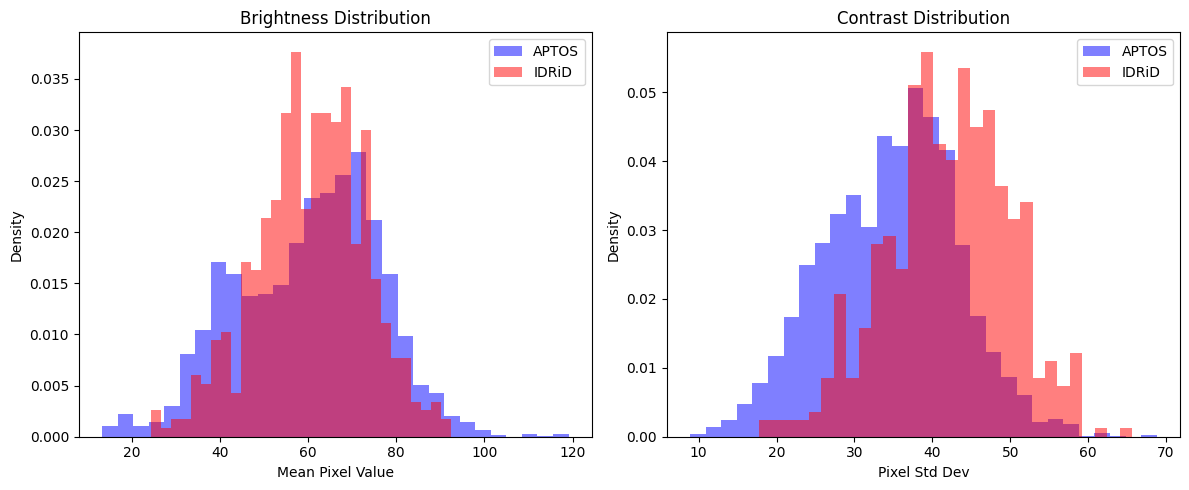

In [114]:
# Brightness and Contrast
fig, axes = plt.subplots(1, 2, figsize=(12, 5))

axes[0].hist(aptos_stats[0], bins=30, alpha=0.5, label='APTOS', color='blue', density=True)
axes[0].hist(idrid_stats[0], bins=30, alpha=0.5, label='IDRiD', color='red', density=True)
axes[0].set_title('Brightness Distribution')
axes[0].set_xlabel('Mean Pixel Value')
axes[0].set_ylabel('Density')
axes[0].legend()

axes[1].hist(aptos_stats[1], bins=30, alpha=0.5, label='APTOS', color='blue', density=True)
axes[1].hist(idrid_stats[1], bins=30, alpha=0.5, label='IDRiD', color='red', density=True)
axes[1].set_title('Contrast Distribution')
axes[1].set_xlabel('Pixel Std Dev')
axes[1].set_ylabel('Density')
axes[1].legend()

plt.tight_layout()
plt.show()

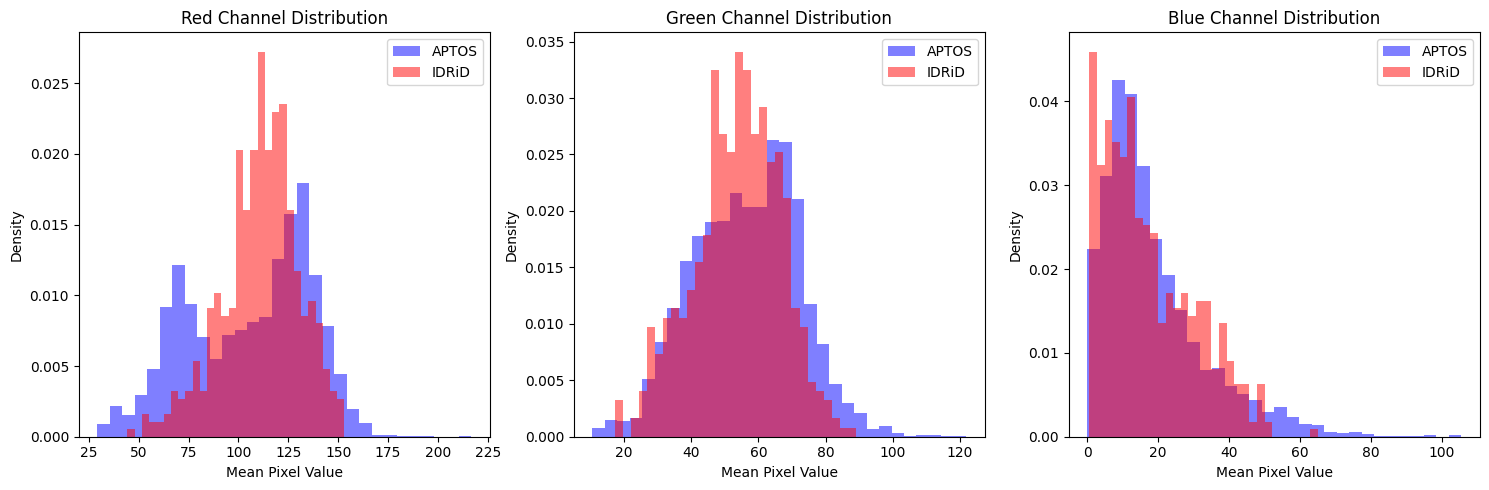

In [115]:
# RGB Channels
fig, axes = plt.subplots(1, 3, figsize=(15, 5))

channels = ['Red', 'Green', 'Blue']
for i, (ax, channel) in enumerate(zip(axes, channels)):
    ax.hist(aptos_stats[i+2], bins=30, alpha=0.5, label='APTOS', color='blue', density=True)
    ax.hist(idrid_stats[i+2], bins=30, alpha=0.5, label='IDRiD', color='red', density=True)
    ax.set_title(f'{channel} Channel Distribution')
    ax.set_xlabel('Mean Pixel Value')
    ax.set_ylabel('Density')
    ax.legend()

plt.tight_layout()
plt.show()

##### Confusion Matrix

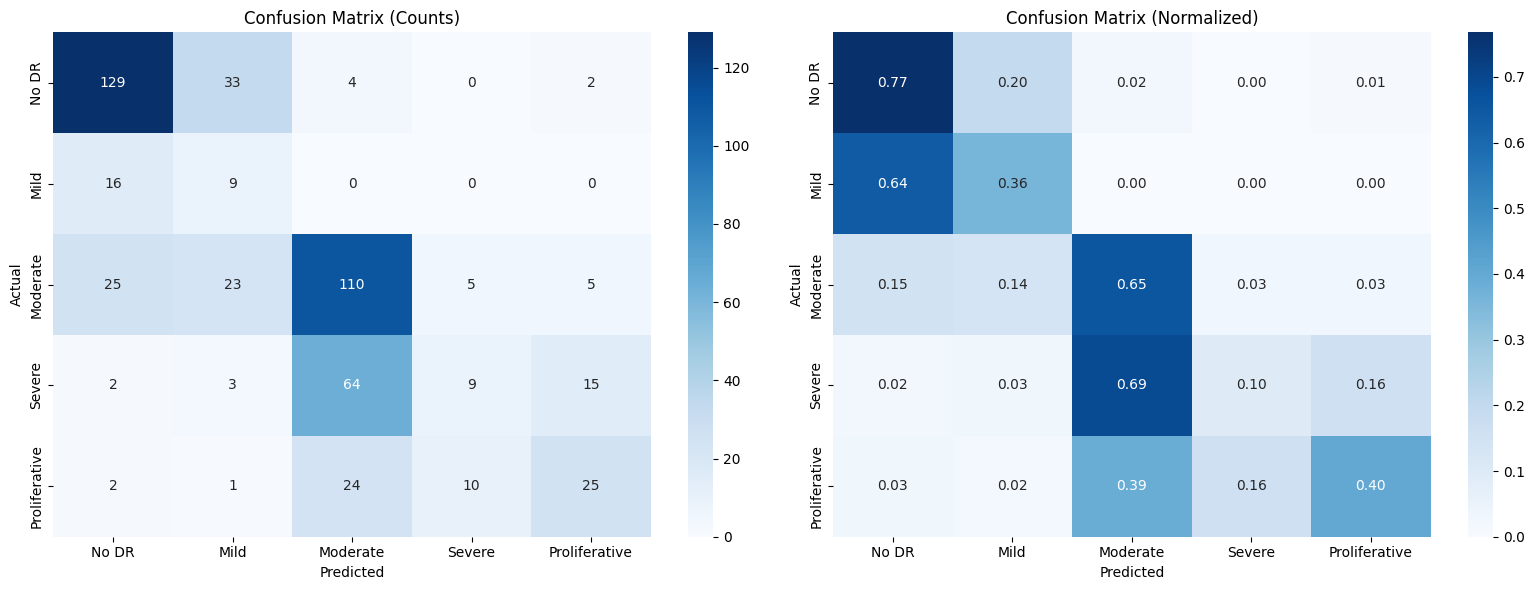

In [126]:
model_v1.eval()

all_preds = []
all_labels = []
with torch.no_grad():
    for images, labels in cross_loader:
        images, labels = images.to(device), labels.to(device)
        outputs = model_v1(images)
        _, predicted = torch.max(outputs.logits, 1)
        all_preds.extend(predicted.cpu().numpy())
        all_labels.extend(labels.cpu().numpy())

cm = confusion_matrix(all_labels, all_preds)
class_names = ['No DR', 'Mild', 'Moderate', 'Severe', 'Proliferative']

fig, axes = plt.subplots(1, 2, figsize=(16, 6))

sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', xticklabels=class_names, 
            yticklabels=class_names, ax=axes[0])
axes[0].set_title('Confusion Matrix (Counts)')
axes[0].set_xlabel('Predicted')
axes[0].set_ylabel('Actual')


cm_norm = cm.astype('float') / cm.sum(axis=1, keepdims=True)
sns.heatmap(cm_norm, annot=True, fmt='.2f', cmap='Blues', xticklabels=class_names,
            yticklabels=class_names, ax=axes[1])
axes[1].set_title('Confusion Matrix (Normalized)')
axes[1].set_xlabel('Predicted')
axes[1].set_ylabel('Actual')

plt.tight_layout()
plt.show()

- Moderate DR dominates predictions (69% of Severe and 39% of Proliferative cases get classified as Moderate)
- Mild DR is almost invisible (64% of Mild cases get predicted as No DR)
- No DR works best (77% recall)

The model pushes everything toward No DR or Moderate. It can't distinguish the finer grades (Mild, Severe, Proliferative) when the image characteristics change.

##### Confidence Analysis

In [128]:
model_v1.eval()

all_conf = []
all_preds = []
all_labels = []

with torch.no_grad():
    for images, labels in cross_loader:
        images, labels = images.to(device), labels.to(device)
        outputs = model_v1(images)
        probs = torch.softmax(outputs.logits, dim=1)
        
        confidence, predicted = torch.max(probs, dim=1)
        
        all_conf.extend(confidence.cpu().numpy())
        all_preds.extend(predicted.cpu().numpy())
        all_labels.extend(labels.cpu().numpy())

Overall accuracy: 54.65%

High confidence (>0.8):
  Count: 320 / 516
  Accuracy: 65.00%

Medium confidence (0.5-0.8):
  Count: 163 / 516
  Accuracy: 41.10%

Low confidence (<0.5):
  Count: 33 / 516
  Accuracy: 21.21%


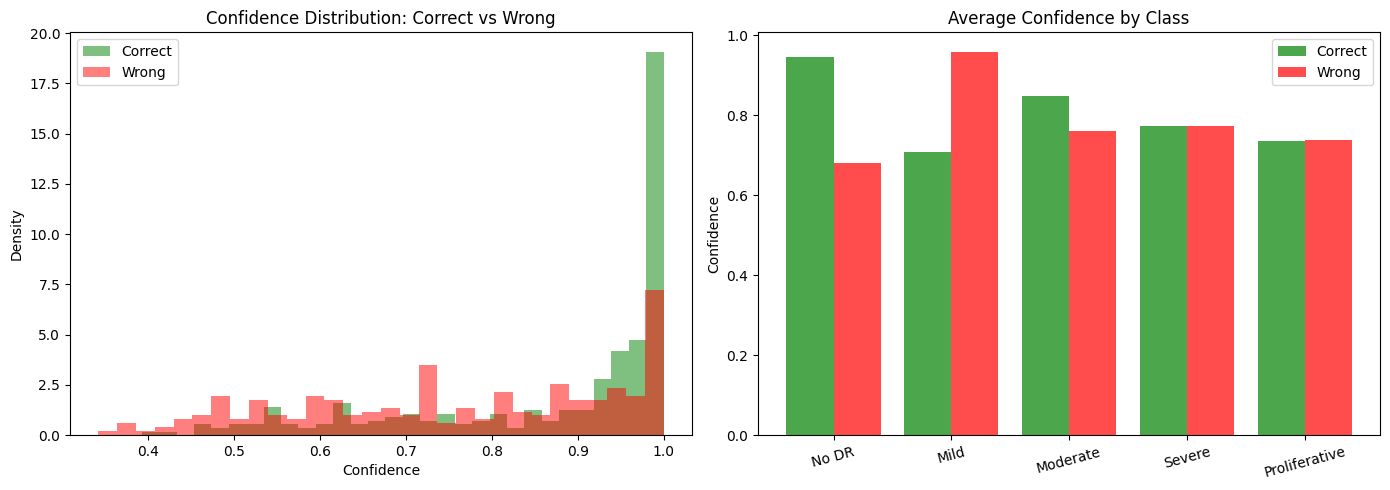

In [129]:
all_conf = np.array(all_conf)
all_preds = np.array(all_preds)
all_labels = np.array(all_labels)
correct = all_preds == all_labels

print(f"Overall accuracy: {correct.mean()*100:.2f}%")

print(f"\nHigh confidence (>0.8):")
high = all_conf > 0.8
print(f"  Count: {high.sum()} / {len(all_conf)}")
print(f"  Accuracy: {correct[high].mean()*100:.2f}%")

print(f"\nMedium confidence (0.5-0.8):")
med = (all_conf >= 0.5) & (all_conf <= 0.8)
print(f"  Count: {med.sum()} / {len(all_conf)}")
print(f"  Accuracy: {correct[med].mean()*100:.2f}%")

print(f"\nLow confidence (<0.5):")
low = all_conf < 0.5
print(f"  Count: {low.sum()} / {len(all_conf)}")
print(f"  Accuracy: {correct[low].mean()*100:.2f}%")

# Plot
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

axes[0].hist(all_conf[correct], bins=30, alpha=0.5, label='Correct', color='green', density=True)
axes[0].hist(all_conf[~correct], bins=30, alpha=0.5, label='Wrong', color='red', density=True)
axes[0].set_title('Confidence Distribution: Correct vs Wrong')
axes[0].set_xlabel('Confidence')
axes[0].set_ylabel('Density')
axes[0].legend()

class_names = ['No DR', 'Mild', 'Moderate', 'Severe', 'Proliferative']
class_conf_correct = []
class_conf_wrong = []
for i in range(5):
    mask = all_labels == i
    class_conf_correct.append(np.mean(all_conf[mask & correct]) if (mask & correct).sum() > 0 else 0)
    class_conf_wrong.append(np.mean(all_conf[mask & ~correct]) if (mask & ~correct).sum() > 0 else 0)

x = np.arange(5)
axes[1].bar(x - 0.2, class_conf_correct, 0.4, label='Correct', color='green', alpha=0.7)
axes[1].bar(x + 0.2, class_conf_wrong, 0.4, label='Wrong', color='red', alpha=0.7)
axes[1].set_xticks(x)
axes[1].set_xticklabels(class_names, rotation=15)
axes[1].set_title('Average Confidence by Class')
axes[1].set_ylabel('Confidence')
axes[1].legend()

plt.tight_layout()
plt.savefig('confidence_analysis.png', dpi=300, bbox_inches='tight')
plt.show()

##### Per class accuracies

In [130]:
print("Per-class accuracy on IDRiD:")
print("-" * 40)
class_names = ['No DR', 'Mild', 'Moderate', 'Severe', 'Proliferative']
for i in range(5):
    mask = all_labels == i
    total = mask.sum()
    correct_count = (correct & mask).sum()
    acc = correct_count / total * 100 if total > 0 else 0
    conf_when_correct = np.mean(all_conf[mask & correct]) if (mask & correct).sum() > 0 else 0
    conf_when_wrong = np.mean(all_conf[mask & ~correct]) if (mask & ~correct).sum() > 0 else 0
    print(f"{class_names[i]:15s}: {acc:5.1f}% ({correct_count}/{total}) "
          f"| Conf correct: {conf_when_correct:.2f} | Conf wrong: {conf_when_wrong:.2f}")

Per-class accuracy on IDRiD:
----------------------------------------
No DR          :  76.8% (129/168) | Conf correct: 0.95 | Conf wrong: 0.68
Mild           :  36.0% (9/25) | Conf correct: 0.71 | Conf wrong: 0.96
Moderate       :  65.5% (110/168) | Conf correct: 0.85 | Conf wrong: 0.76
Severe         :   9.7% (9/93) | Conf correct: 0.77 | Conf wrong: 0.77
Proliferative  :  40.3% (25/62) | Conf correct: 0.74 | Conf wrong: 0.74


When the dataset changes, rare classes suffer the most.

Even after applying class-balancing techniques such as weighted random sampling, cross-dataset performance degradation persists, indicating that domain shift rather than class imbalance is the primary factor limiting generalization.

In [132]:
from pytorch_grad_cam import GradCAM
from pytorch_grad_cam.utils.image import show_cam_on_image
from pytorch_grad_cam.utils.model_targets import ClassifierOutputTarget

##### Grad-CAM

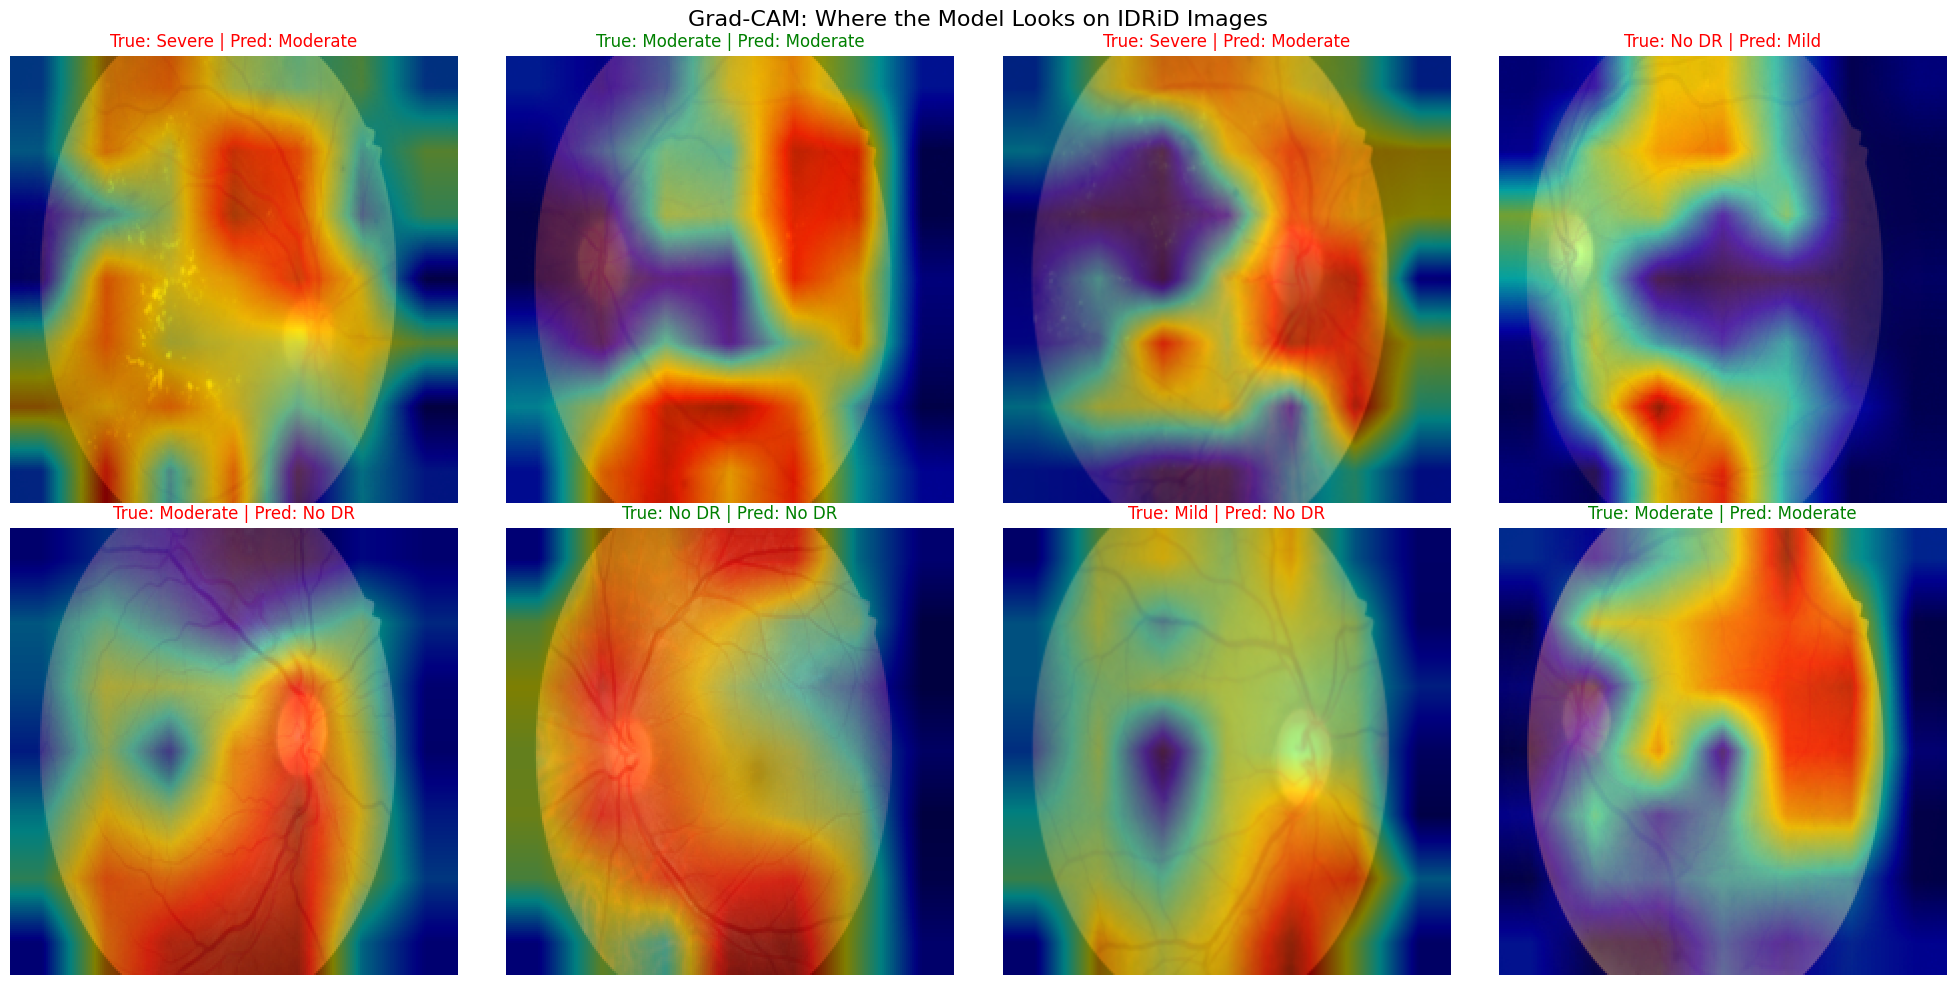

In [134]:
from pytorch_grad_cam import GradCAM
from pytorch_grad_cam.utils.image import show_cam_on_image
from pytorch_grad_cam.utils.model_targets import ClassifierOutputTarget

class HuggingFaceModelWrapper(torch.nn.Module):
    def __init__(self, model):
        super().__init__()
        self.model = model
    
    def forward(self, x):
        return self.model(x).logits

wrapped_model = HuggingFaceModelWrapper(model_v1)

# Reshape function for Swin's 3D output to 4D
def reshape_transform(tensor, height=7, width=7):
    # tensor shape: (batch, num_tokens, channels)
    result = tensor.reshape(tensor.size(0), height, width, tensor.size(2))
    # Convert to (batch, channels, height, width)
    result = result.permute(0, 3, 1, 2)
    return result

target_layer = model_v1.swin.encoder.layers[-1].blocks[-1].layernorm_before

cam = GradCAM(
    model=wrapped_model,
    target_layers=[target_layer],
    reshape_transform=reshape_transform
)

# Pick some IDRiD images to visualize — get a few correct and wrong predictions
def show_gradcam(image_path, true_label, model, cam, transform):
    image = Image.open(image_path).convert('RGB')
    input_tensor = transform(image).unsqueeze(0).to(device)
    
    # Get prediction
    with torch.no_grad():
        output = model(input_tensor)
        _, predicted = torch.max(output, 1)
    
    # Generate GradCAM
    targets = [ClassifierOutputTarget(predicted.item())]
    grayscale_cam = cam(input_tensor=input_tensor, targets=targets)[0]
    
    # Overlay on original image
    img_resized = np.array(image.resize((224, 224))) / 255.0
    visualization = show_cam_on_image(img_resized, grayscale_cam, use_rgb=True)
    
    return visualization, predicted.item(), true_label

# Get some sample images
class_names = ['No DR', 'Mild', 'Moderate', 'Severe', 'Proliferative']

# Pick 8 images — mix of correct and wrong predictions
sample_indices = [0, 50, 100, 150, 200, 250, 300, 400]

fig, axes = plt.subplots(2, 4, figsize=(20, 10))
for idx, ax in zip(sample_indices, axes.flat):
    img_path = all_data.iloc[idx]['full_path']
    true_label = int(all_data.iloc[idx]['Retinopathy grade'])
    
    vis, pred, true = show_gradcam(img_path, true_label, wrapped_model, cam, transform_val)
    
    color = 'green' if pred == true else 'red'
    ax.imshow(vis)
    ax.set_title(f'True: {class_names[true]} | Pred: {class_names[pred]}', color=color)
    ax.axis('off')

plt.suptitle('Grad-CAM: Where the Model Looks on IDRiD Images', fontsize=16)
plt.tight_layout()
plt.savefig('gradcam_analysis.png', dpi=300, bbox_inches='tight')
plt.show()

- Background and edges get attention. Different cameras produce different borders, which explains why cross-dataset fails
- The model focuses on broad regions, not specific lesions. The attention maps show large red/yellow areas covering half the retina rather than focusing on specific hemorrhages, microaneurysms, or exudates.